# AUV image footprint + coverage area
- note this is not area surveyed unless species specific altitude threshold is set

Computes for each AUV image (given lat/long, altitude, pitch/roll/yaw at capture time):
- the seafloor footprint polygon of that image (a trapezoid once pitch/roll != 0, not a rectangle)
- the footprint area
- the total *unique* area covered by the whole image set, accounting for overlap between images


In [1]:
import math
import json

import numpy as np
import pandas as pd
from pyproj import Transformer, CRS
from shapely.geometry import Polygon
from shapely.ops import unary_union


### Config

- `HFOV_DEG`: 48.5 deg from the Cathx spec sheet. This is assumed to be the **horizontal** FOV
  (across image width). If it's actually the diagonal FOV instead, set `FOV_IS_HORIZONTAL = False`.
- `PITCH_SIGN` / `ROLL_SIGN` / `YAW_SIGN`: sign conventions for how pitch/roll/yaw rotate the
  camera. Standard AUV/NED convention is assumed (yaw = compass heading, pitch = nose up(+)/down(-),
  roll = right side down(+)/up(-)). 
  *If footprints come out mirrored or rotated 90 deg off from your
  actual track heading when you check them in QGIS, flip the relevant sign here and re-run.


In [12]:
# set up file pathways

base_path = r"C:\Users\a39799\OneDrive - Danmarks Tekniske Universitet\Documents\AUV\kathy_loppa"
mission = "Mission_59_20260712_2" #"Mission_59_20260709_1"

INPUT_CSV = rf"{base_path}\{mission}_image_metadata.csv"   # path to merged XML log, OR a folder if INPUT_IS_DIR
#INPUT_IS_DIR = False              # True if INPUT_PATH is a folder of one-XML-per-image
 
OUTPUT_CSV = rf"{base_path}\{mission}_image_footprints.csv"
OUTPUT_GEOJSON = rf"{base_path}\{mission}_image_footprints.geojson"

IMAGE_WIDTH_PX = 4096             # <-- (pixels)
IMAGE_HEIGHT_PX = 2304            # <-- (pixels)
HFOV_DEG = 48.5                   # found this https://www.hi.no/en/hi/nettrapporter/toktrapport-en-2023-6 and also but not in a manual
FOV_IS_HORIZONTAL = True          # False if 48.5 deg is actually the diagonal FOV
 
# --- sign conventions, flip if footprints look mirrored/rotated wrong ---
PITCH_SIGN = 1.0
ROLL_SIGN = 1.0
YAW_SIGN = 1.0

## Geometry helper functions

**Where does focal length come in?**

It doesn't, directly -- and that's fine. In a full pinhole camera model, a ray direction for a
pixel offset from the image centre is `pixel_offset_mm / focal_length_mm`, and focal length relates
to field of view (FOV) by `tan(FOV/2) = sensor_half_width / focal_length`. Since we're given FOV
(48.5 deg) rather than focal length + sensor size, we skip straight to computing `tan(half_FOV)`
in `build_camera_ray_dirs()` below -- that ratio *is* effectively `sensor_half_width / focal_length`.
FOV and focal length are two ways of expressing the same optical property (for a fixed sensor size),
so nothing is lost by using FOV directly; it's actually the more direct route here. (If you ever get
real calibrated intrinsics -- fx, fy, cx, cy -- from a calibration file, that would let you also
correct for lens distortion and an off-centre principal point, but for a rectilinear lens assumed
centred, this FOV-based approach gives the identical answer.)

**The overall geometry pipeline:**

1. `compute_vfov_deg`: you only have horizontal FOV; vertical FOV is derived from the image's
   aspect ratio (width/height in pixels), assuming a rectilinear (non-fisheye) lens.
2. `rot_x/rot_y/rot_z` + `body_to_ned_matrix`: build the rotation matrix that takes a direction
   vector in the AUV's own body frame (x=forward, y=right, z=down) and expresses it in the local
   North-East-Down (NED) navigation frame, using the vehicle's yaw/pitch/roll at capture time.
3. `build_camera_ray_dirs`: cast one ray per image corner (top-left, top-right, bottom-right,
   bottom-left) in the camera/body frame, using the half-FOV angles as the ray's horizontal/vertical
   "slope". This assumes the camera boresight = body +Z axis (points straight down when
   pitch=roll=0), i.e. no separate camera-to-body mounting tilt. If your camera is mounted at a
   fixed angle relative to the vehicle body, that fixed rotation should be applied to these
   directions too (see comment inside the function).
4. `footprint_corners_ned`: rotate each body-frame ray into the NED frame using the vehicle's
   actual attitude, then intersect it with the flat seafloor plane sitting at `altitude` metres
   below the vehicle (straight-down distance, i.e. a typical altimeter reading) -- this gives the
   four corners of the image footprint as north/east offsets (in metres) from the vehicle.


In [5]:
def compute_vfov_deg(hfov_deg, width_px, height_px, fov_is_horizontal=True):
    """Derive the other FOV axis from a rectilinear-lens FOV + image aspect ratio."""
    aspect = width_px / height_px  # e.g. 2464/2056 ~= 1.2
    if fov_is_horizontal:
        half_h = math.radians(hfov_deg / 2.0)
        half_v = math.atan(math.tan(half_h) / aspect)
        return math.degrees(2 * half_v)
    else:
        # given value was the DIAGONAL FOV; solve for horizontal & vertical using
        # tan(half_diagonal)^2 = tan(half_h)^2 + tan(half_v)^2, with tan(half_h) = aspect * tan(half_v)
        half_d = math.radians(hfov_deg / 2.0)
        tan_d = math.tan(half_d)
        tan_v = tan_d / math.sqrt(1 + aspect ** 2)
        tan_h = aspect * tan_v
        return math.degrees(2 * math.atan(tan_h)), math.degrees(2 * math.atan(tan_v))


In [6]:
# --- basic 3D rotation matrices (right-handed, radians internally, degrees in/out) ---

def rot_x(deg):
    """Rotation about the X (forward) axis -- this is what ROLL does."""
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rot_y(deg):
    """Rotation about the Y (right) axis -- this is what PITCH does."""
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])


def rot_z(deg):
    """Rotation about the Z (down) axis -- this is what YAW does."""
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def body_to_ned_matrix(yaw_deg, pitch_deg, roll_deg):
    """
    Returns R such that: v_ned = R @ v_body
    i.e. R converts a direction vector expressed in the vehicle's own body frame
    (x=forward, y=right, z=down) into the local North-East-Down navigation frame,
    given the vehicle's current yaw/pitch/roll. Standard aerospace/marine convention:
    apply yaw first, then pitch, then roll (R = Rz(yaw) @ Ry(pitch) @ Rx(roll)).
    """
    Rz = rot_z(YAW_SIGN * yaw_deg)
    Ry = rot_y(PITCH_SIGN * pitch_deg)
    Rx = rot_x(ROLL_SIGN * roll_deg)
    return Rz @ Ry @ Rx


In [7]:
def build_camera_ray_dirs(hfov_deg, vfov_deg):
    """
    Unit ray directions (in BODY frame) through the 4 image corners, in the order
    [top-left, top-right, bottom-right, bottom-left] as seen when looking at the image.
    Body frame axes: x=forward, y=right, z=down (the boresight / optical axis when
    pitch=roll=0, i.e. looking straight down).

    tan(half_h) and tan(half_v) below play the role that (pixel_offset_mm / focal_length_mm)
    would play in a full intrinsics-based projection -- see the markdown cell above for why
    that's equivalent to what we're doing here with FOV directly.

    NOTE ON CAMERA MOUNTING: this assumes the camera points exactly along the body's +Z axis
    (straight down at pitch=roll=0). If your camera is physically mounted at a fixed tilt
    relative to the vehicle body (e.g. pitched 10 deg forward of nadir), left-multiply each
    direction vector below by that fixed rotation matrix before returning.
    """
    half_h = math.radians(hfov_deg / 2.0)
    half_v = math.radians(vfov_deg / 2.0)
    tan_h = math.tan(half_h)
    tan_v = math.tan(half_v)

    # u = left/right offset (horizontal, maps to body's right axis)
    # v = up/down offset (vertical, maps to body's forward axis -- "up" in the image
    #     corresponds to "toward the front of the vehicle")
    corners_uv = {
        "top_left": (-tan_h, tan_v),
        "top_right": (tan_h, tan_v),
        "bottom_right": (tan_h, -tan_v),
        "bottom_left": (-tan_h, -tan_v),
    }

    dirs = {}
    for name, (u, v) in corners_uv.items():
        d = np.array([v, u, 1.0])  # (forward, right, down) -- down=1 is the boresight component
        dirs[name] = d / np.linalg.norm(d)  # normalize to a unit vector
    return dirs


def footprint_corners_ned(yaw, pitch, roll, altitude, ray_dirs_body):
    """
    For one image: rotate each body-frame corner ray into the NED frame using the
    vehicle's attitude, then intersect it with the flat seafloor plane at depth
    `altitude` below the vehicle. Returns dict of corner_name -> (north_m, east_m)
    offset from the vehicle's position.
    """
    R = body_to_ned_matrix(yaw, pitch, roll)
    out = {}
    for name, d_body in ray_dirs_body.items():
        d_ned = R @ d_body  # rotate ray direction into the NED frame
        if d_ned[2] <= 1e-6:
            # ray points sideways/upward rather than down -- happens only at extreme
            # pitch/roll -- it will never hit the seafloor plane, so flag and skip
            out[name] = None
            continue
        # scale factor t such that the ray's "down" component reaches `altitude`
        t = altitude / d_ned[2]
        north = t * d_ned[0]
        east = t * d_ned[1]
        out[name] = (north, east)
    return out


## Load metadata CSV

Reads your CSV directly with pandas. Only the columns actually needed for the geometry are
pulled out (`lat`, `long`, `altitude`, `pitch`, `roll`, `yaw`)


In [8]:
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} rows from {INPUT_CSV}")
df.head()


Loaded 10235 rows from C:\Users\a39799\OneDrive - Danmarks Tekniske Universitet\Documents\AUV\kathy_loppa\Mission_59_20260712_2_image_metadata.csv


,filename,image_time,image_date,acq_index,lat,long,altitude,depth,pitch,roll,yaw,exposure,digital_gain,analog_gain,sensor_gain,aperture,focus,camera_name,session_name,serial_number
0,image_D2026-07-12T13-33-53-502252Z_0.jpg,13:33:53.502252,2026.07.12,5156,70.134954,21.259451,47.54,277.06,-0.98,0.03,291.72,1250,1.25,6,4,1.4,800,ColorCamera,cxcon_0,238
1,image_D2026-07-12T13-33-53-835580Z_1.jpg,13:33:53.835580,2026.07.12,5157,70.134957,21.259432,47.76,277.06,-0.95,0.05,292.37,1250,1.25,6,4,1.4,800,ColorCamera,cxcon_0,238
2,image_D2026-07-12T13-33-54-168923Z_2.jpg,13:33:54.168923,2026.07.12,5158,70.134958,21.259417,47.76,277.06,-0.91,0.06,292.93,1250,1.25,6,4,1.4,800,ColorCamera,cxcon_0,238
3,image_D2026-07-12T13-33-54-502249Z_0.jpg,13:33:54.502249,2026.07.12,5159,70.134960,21.259403,47.90,277.06,-0.88,0.15,293.57,1500,1.25,6,4,1.4,800,ColorCamera,cxcon_0,238
4,image_D2026-07-12T13-33-54-835581Z_1.jpg,13:33:54.835581,2026.07.12,5160,70.134963,21.259385,47.92,277.05,-0.83,0.11,294.52,1500,1.25,6,4,1.4,800,ColorCamera,cxcon_0,238


## Set up field of view and coordinate projection

- Derives vertical FOV from horizontal FOV + image aspect ratio.
- Picks a UTM zone automatically based on your survey's location (first row's lat/long),
  and builds transformers to convert between lat/long (WGS84) and UTM metres. All area calculations
  happens in UTM metres, not lat/long degrees, since degree-based area isn't metrically
  meaningful (a degree of longitude is a different physical distance depending on latitude).


In [9]:
if FOV_IS_HORIZONTAL:
    hfov_deg = HFOV_DEG
    vfov_deg = compute_vfov_deg(HFOV_DEG, IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX, True)
else:
    hfov_deg, vfov_deg = compute_vfov_deg(HFOV_DEG, IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX, False)
print(f"HFOV = {hfov_deg:.2f} deg, VFOV (derived) = {vfov_deg:.2f} deg")

ray_dirs_body = build_camera_ray_dirs(hfov_deg, vfov_deg)

# auto-pick UTM zone from the first row's position
lat0, lon0 = df.iloc[0]["lat"], df.iloc[0]["long"]
utm_zone = int(math.floor((lon0 + 180) / 6) + 1)
hemisphere_epsg = 32600 + utm_zone if lat0 >= 0 else 32700 + utm_zone   # 326xx = N hemisphere, 327xx = S
utm_crs = CRS.from_epsg(hemisphere_epsg)
to_utm = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True)
to_wgs84 = Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)
print(f"Using UTM CRS: EPSG:{hemisphere_epsg} (zone {utm_zone})")


HFOV = 48.50 deg, VFOV (derived) = 28.44 deg
Using UTM CRS: EPSG:32634 (zone 34)


## Compute per-image footprint polygons

For every row: project the vehicle position to UTM, compute the 4 corner offsets via
`footprint_corners_ned`, add them to the vehicle's UTM position to get absolute corner
coordinates, and build a `shapely` polygon from them. `poly.area` is the image's footprint
area in square metres.


In [10]:
polygons = []
rows = []
skipped = 0
skipped_reasons = []

REQUIRED_COLS = ["lat", "long", "altitude", "pitch", "roll", "yaw"]

for idx, rec in df.iterrows():
    # --- guard against missing/NaN values in required fields (e.g. dropped GPS fix,
    # missing altimeter reading) -- without this check, a NaN silently propagates through
    # the geometry and shapely throws a cryptic GEOSException ("Points of LinearRing do
    # not form a closed linestring") when it tries to build the polygon, since NaN != NaN
    # breaks the ring-closure check ---
    if rec[REQUIRED_COLS].isna().any():
        skipped += 1
        bad_cols = [c for c in REQUIRED_COLS if pd.isna(rec[c])]
        skipped_reasons.append((rec.get("filename", idx), f"missing/NaN: {bad_cols}"))
        continue

    easting0, northing0 = to_utm.transform(rec["long"], rec["lat"])

    corners_ned = footprint_corners_ned(
        rec["yaw"], rec["pitch"], rec["roll"], rec["altitude"], ray_dirs_body
    )

    if any(v is None for v in corners_ned.values()):
        skipped += 1
        skipped_reasons.append((rec.get("filename", idx), "ray did not hit seafloor plane (extreme pitch/roll)"))
        continue

    # corner order matters here -- must trace the polygon boundary in order,
    # not e.g. diagonally, or shapely will build a self-intersecting "bowtie" shape
    order = ["top_left", "top_right", "bottom_right", "bottom_left"]
    utm_pts = []
    latlon_pts = []
    for name in order:
        north, east = corners_ned[name]
        e = easting0 + east
        n = northing0 + north
        utm_pts.append((e, n))
        lon, lat = to_wgs84.transform(e, n)
        latlon_pts.append((lon, lat))

    poly = Polygon(utm_pts)
    if not poly.is_valid or poly.area == 0:
        skipped += 1
        skipped_reasons.append((rec.get("filename", idx), "degenerate/invalid polygon"))
        continue

    polygons.append(poly)
    rows.append({
        "filename": rec.get("filename", None),
        "acq_index": rec.get("acq_index", None),
        "image_time": rec.get("image_time", None),
        "image_date": rec.get("image_date", None),
        "lat": rec["lat"],
        "long": rec["long"],
        "altitude": rec["altitude"],
        "pitch": rec["pitch"],
        "roll": rec["roll"],
        "yaw": rec["yaw"],
        "area_m2": poly.area,
        "corner_latlon": latlon_pts,
    })

if skipped:
    print(f"WARNING: skipped {skipped} images:")
    for name, reason in skipped_reasons[:20]:
        print(f"  - {name}: {reason}")
    if len(skipped_reasons) > 20:
        print(f"  ... and {len(skipped_reasons) - 20} more (see skipped_reasons list)")
print(f"Computed footprints for {len(polygons)} images")


Computed footprints for 10235 images


## Save outputs

- `image_footprints.csv`: one row per image with its footprint area and corner lat/longs.
- `image_footprints.geojson`: all footprint polygons, for loading into QGIS to visually check
  they trail sensibly along the AUV track before trusting the numbers.


In [13]:
out_df = pd.DataFrame(rows)
out_df_to_save = out_df.copy()
out_df_to_save["corner_latlon"] = out_df_to_save["corner_latlon"].apply(json.dumps)
out_df_to_save.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote per-image areas to {OUTPUT_CSV}")

features = []
for r, poly in zip(rows, polygons):
    ring = r["corner_latlon"] + [r["corner_latlon"][0]]  # close the polygon ring
    features.append({
        "type": "Feature",
        "properties": {"filename": r["filename"], "acq_index": r["acq_index"], "area_m2": r["area_m2"]},
        "geometry": {"type": "Polygon", "coordinates": [ring]},
    })
with open(OUTPUT_GEOJSON, "w") as f:
    json.dump({"type": "FeatureCollection", "features": features}, f)
print(f"Wrote footprint polygons to {OUTPUT_GEOJSON}")


Wrote per-image areas to C:\Users\a39799\OneDrive - Danmarks Tekniske Universitet\Documents\AUV\kathy_loppa\Mission_59_20260712_2_image_footprints.csv
Wrote footprint polygons to C:\Users\a39799\OneDrive - Danmarks Tekniske Universitet\Documents\AUV\kathy_loppa\Mission_59_20260712_2_image_footprints.geojson


## Coverage summary

`unary_union` merges all footprint polygons into their combined shape, deduplicating any
overlapping area -- its `.area` is the true unique seafloor area covered by the survey.


In [14]:
total_individual_area = sum(p.area for p in polygons)
union_geom = unary_union(polygons)
union_area = union_geom.area
overlap_area = total_individual_area - union_area
overlap_frac = overlap_area / total_individual_area if total_individual_area else 0

print("--- Coverage summary ---")
print(f"Images used:                 {len(polygons)}")
print(f"Sum of individual areas:     {total_individual_area:,.2f} m^2 (double-counts overlap)")
print(f"Unique covered area (union): {union_area:,.2f} m^2")
print(f"Overlap area:                {overlap_area:,.2f} m^2")
print(f"Overlap fraction of total:   {overlap_frac:.1%}")

out_df.sort_values("area_m2").head()  # quick look, e.g. to spot suspiciously small/large footprints




--- Coverage summary ---
Images used:                 10235
Sum of individual areas:     9,414,681.93 m^2 (double-counts overlap)
Unique covered area (union): 141,594.39 m^2
Overlap area:                9,273,087.54 m^2
Overlap fraction of total:   98.5%


,filename,acq_index,image_time,image_date,lat,long,altitude,pitch,roll,yaw,area_m2,corner_latlon
7936,image_D2026-07-12T14-29-00-478329Z_2.jpg,15077,14:29:00.478329,2026.07.12,70.131450,21.300805,2.81,-0.68,-0.01,82.72,3.605961,"[(21.30081865281009, 70.13146216693073), (21.3..."
7935,image_D2026-07-12T14-29-00-145002Z_1.jpg,15076,14:29:00.145002,2026.07.12,70.131450,21.300790,2.81,-0.97,0.05,82.74,3.606822,"[(21.300802874100995, 70.13146176714274), (21...."
7934,image_D2026-07-12T14-28-59-811668Z_0.jpg,15075,14:28:59.811668,2026.07.12,70.131449,21.300774,2.84,-1.26,0.02,82.75,3.685425,"[(21.300786931539214, 70.13146114822355), (21...."
7938,image_D2026-07-12T14-29-01-144998Z_1.jpg,15079,14:29:01.144998,2026.07.12,70.131452,21.300842,2.86,0.05,-0.11,82.68,3.734603,"[(21.300856574043493, 70.13146400771153), (21...."
7937,image_D2026-07-12T14-29-00-811671Z_0.jpg,15078,14:29:00.811671,2026.07.12,70.131451,21.300826,2.86,-0.26,-0.15,82.69,3.734746,"[(21.300840457280934, 70.13146325173389), (21...."


## (Optional) Quick plot of footprints

A fast sanity check without leaving the notebook -- plots all footprint polygons in UTM
metres. Look for a sensible track shape and consistent, plausible overlap between
consecutive images; wildly rotated or non-adjacent footprints usually mean a sign
convention (`PITCH_SIGN`/`ROLL_SIGN`/`YAW_SIGN`) needs flipping.


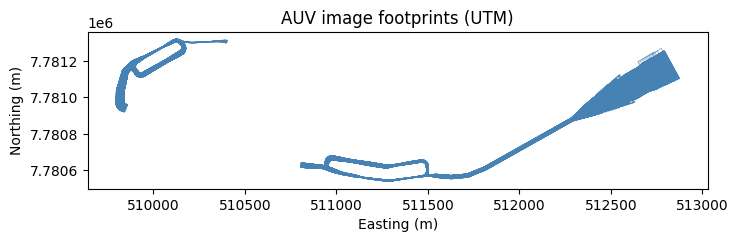

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

fig, ax = plt.subplots(figsize=(8, 8))
for poly in polygons:
    xs, ys = poly.exterior.xy
    ax.plot(xs, ys, color="steelblue", linewidth=0.5, alpha=0.6)
ax.set_aspect("equal")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("AUV image footprints (UTM)")
plt.show()


## Inspect a subset of images

Pick a handful of images by `filename` (or swap to `acq_index` -- see comment below) and plot
just their footprints, labeled and color-coded, with the AUV position marked for each. Useful
for zooming in on a specific stretch of the survey to sanity-check overlap between neighbouring
shots, rather than looking at the whole (potentially huge) footprint plot at once.

In [16]:
# --- pick images to inspect ---
SELECTED_FILENAMES = ["image_D2026-07-09T11-03-05-759001Z_2.jpg", "image_D2026-07-09T11-03-06-092325Z_0.jpg"]
# ["image_D2026-07-09T12-07-07-730137Z_2.jpg", "image_D2026-07-09T12-07-08-063473Z_0.jpg", "image_D2026-07-09T12-07-08-396806Z_1.jpg"]
#["image_D2026-07-09T11-03-05-759001Z_2.jpg", "image_D2026-07-09T11-03-06-092325Z_0.jpg"]
    # put 3-4 filenames from your CSV here, e.g.:
    # "image_D2026-07-09T09-04-32-475405Z_1.jpg",
    # "image_D2026-07-09T09-04-33-475405Z_2.jpg",

# alternative: select by acq_index instead of filename -- uncomment and use this
# instead of SELECTED_FILENAMES if that's more convenient for your dataset
SELECTED_ACQ_INDEX = [27642, 27643, 27644]
selected_rows = [(r, p) for r, p in zip(rows, polygons) if r["acq_index"] in SELECTED_ACQ_INDEX]

selected_rows = [(r, p) for r, p in zip(rows, polygons) if r["filename"] in SELECTED_FILENAMES]

if not selected_rows:
    print("No matching images found -- check SELECTED_FILENAMES against out_df['filename'] below.")
    print(out_df[["filename", "acq_index"]].head(10))
else:
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.tab10.colors

    for i, (r, poly) in enumerate(selected_rows):
        color = colors[i % len(colors)]
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color=color, alpha=0.25)
        ax.plot(xs, ys, color=color, linewidth=1.5, label=r["filename"] or r["acq_index"])

        # mark the AUV position (footprint centroid's not the same as vehicle position when
        # pitch/roll != 0, so re-derive the vehicle's own UTM point for an accurate marker)
        veh_e, veh_n = to_utm.transform(r["long"], r["lat"])
        ax.plot(veh_e, veh_n, marker="x", color=color, markersize=8, markeredgewidth=2)

        # label near the polygon centroid
        cx, cy = poly.centroid.x, poly.centroid.y
        ax.annotate(str(r["acq_index"]), (cx, cy), fontsize=8, ha="center", color=color)

    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(f"Footprints for {len(selected_rows)} selected images (x = AUV position)")
    ax.legend(fontsize=7, loc="best")
    plt.show()

    # areas + pairwise overlap for just this subset
    print("\nSelected image areas:")
    for r, poly in selected_rows:
        print(f"  {r['filename'] or r['acq_index']}: {poly.area:.2f} m^2")

    subset_union = unary_union([p for _, p in selected_rows])
    subset_total = sum(p.area for _, p in selected_rows)
    print(f"\nSum of areas:     {subset_total:.2f} m^2")
    print(f"Union (unique):   {subset_union.area:.2f} m^2")
    print(f"Overlap:          {subset_total - subset_union.area:.2f} m^2")


No matching images found -- check SELECTED_FILENAMES against out_df['filename'] below.
                                   filename  acq_index
0  image_D2026-07-12T13-33-53-502252Z_0.jpg       5156
1  image_D2026-07-12T13-33-53-835580Z_1.jpg       5157
2  image_D2026-07-12T13-33-54-168923Z_2.jpg       5158
3  image_D2026-07-12T13-33-54-502249Z_0.jpg       5159
4  image_D2026-07-12T13-33-54-835581Z_1.jpg       5160
5  image_D2026-07-12T13-33-55-168900Z_2.jpg       5161
6  image_D2026-07-12T13-33-55-502243Z_0.jpg       5162
7  image_D2026-07-12T13-33-55-835571Z_1.jpg       5163
8  image_D2026-07-12T13-33-56-168898Z_2.jpg       5164
9  image_D2026-07-12T13-33-56-502228Z_0.jpg       5165


279 of 10235 images have altitude < 4.0 m

--- Coverage summary (altitude < 4.0 m) ---
Images used:                 279
Sum of individual areas:     1,620.04 m^2 (double-counts overlap)
Unique covered area (union): 573.66 m^2
Overlap area:                1,046.38 m^2
Overlap fraction of total:   64.6%


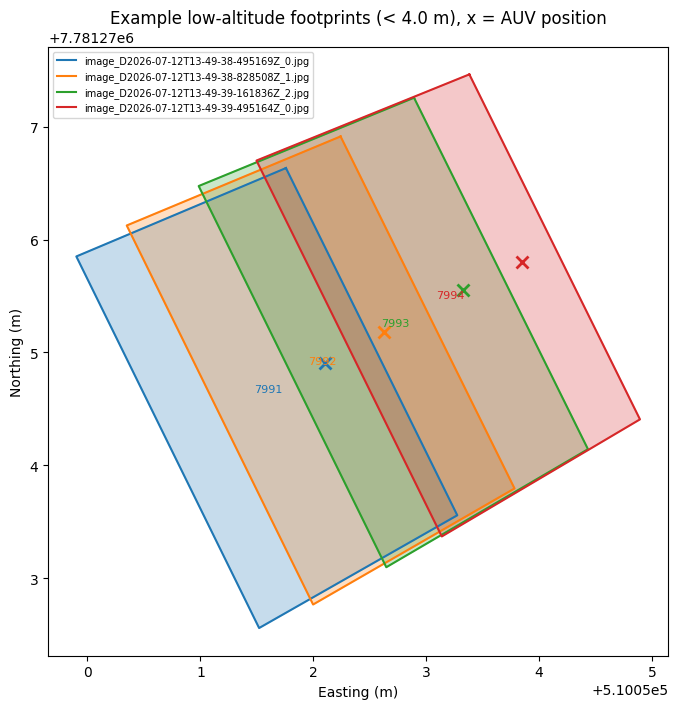


Example image areas:
  image_D2026-07-12T13-49-38-495169Z_0.jpg (altitude=3.90 m): 7.14 m^2
  image_D2026-07-12T13-49-38-828508Z_1.jpg (altitude=3.96 m): 7.40 m^2
  image_D2026-07-12T13-49-39-161836Z_2.jpg (altitude=3.96 m): 7.45 m^2
  image_D2026-07-12T13-49-39-495164Z_0.jpg (altitude=3.89 m): 7.23 m^2

Sum of areas:     29.23 m^2
Union (unique):   13.90 m^2
Overlap:          15.34 m^2


In [17]:
# reducing to images likely to be used
ALTITUDE_THRESHOLD_M = 4.0

low_alt_pairs = [(r, p) for r, p in zip(rows, polygons) if r["altitude"] < ALTITUDE_THRESHOLD_M]
print(f"{len(low_alt_pairs)} of {len(rows)} images have altitude < {ALTITUDE_THRESHOLD_M} m")

if not low_alt_pairs:
    print("No images below this altitude threshold -- nothing further to show.")
else:
    low_alt_rows = [r for r, _ in low_alt_pairs]
    low_alt_polys = [p for _, p in low_alt_pairs]

    # --- coverage summary, scoped to this subset (same logic as the full-dataset summary) ---
    total_individual_area = sum(p.area for p in low_alt_polys)
    union_geom = unary_union(low_alt_polys)
    union_area = union_geom.area
    overlap_area = total_individual_area - union_area
    overlap_frac = overlap_area / total_individual_area if total_individual_area else 0

    print("\n--- Coverage summary (altitude < {:.1f} m) ---".format(ALTITUDE_THRESHOLD_M))
    print(f"Images used:                 {len(low_alt_polys)}")
    print(f"Sum of individual areas:     {total_individual_area:,.2f} m^2 (double-counts overlap)")
    print(f"Unique covered area (union): {union_area:,.2f} m^2")
    print(f"Overlap area:                {overlap_area:,.2f} m^2")
    print(f"Overlap fraction of total:   {overlap_frac:.1%}")

    # --- plot a handful of example footprints from this subset (first N found) ---
    N_EXAMPLES = 4
    example_pairs = low_alt_pairs[:N_EXAMPLES]

    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.tab10.colors

    for i, (r, poly) in enumerate(example_pairs):
        color = colors[i % len(colors)]
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color=color, alpha=0.25)
        ax.plot(xs, ys, color=color, linewidth=1.5, label=r["filename"] or r["acq_index"])

        veh_e, veh_n = to_utm.transform(r["long"], r["lat"])
        ax.plot(veh_e, veh_n, marker="x", color=color, markersize=8, markeredgewidth=2)

        cx, cy = poly.centroid.x, poly.centroid.y
        ax.annotate(str(r["acq_index"]), (cx, cy), fontsize=8, ha="center", color=color)

    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(f"Example low-altitude footprints (< {ALTITUDE_THRESHOLD_M} m), x = AUV position")
    ax.legend(fontsize=7, loc="best")
    plt.show()

    print("\nExample image areas:")
    for r, poly in example_pairs:
        print(f"  {r['filename'] or r['acq_index']} (altitude={r['altitude']:.2f} m): {poly.area:.2f} m^2")

    example_union = unary_union([p for _, p in example_pairs])
    example_total = sum(p.area for _, p in example_pairs)
    print(f"\nSum of areas:     {example_total:.2f} m^2")
    print(f"Union (unique):   {example_union.area:.2f} m^2")
    print(f"Overlap:          {example_total - example_union.area:.2f} m^2")


# Conclusion
Due to the high overlap between images I must explicitly account for duplicate detections
Once option is to mosaic images together - but then I may loose animals which can move- or still double count. 
Use Nils past technique of calculating density per image and averaging over 5m2 areas.